# **1. Perkenalan Dataset**


# 1. Perkenalan Dataset
- **Nama Dataset:** Telco Customer Churn
- **Sumber:** Kaggle (https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
- **Tujuan:** Memprediksi pelanggan yang akan berhenti berlangganan (churn) berdasarkan data demografi dan layanan.
- **Task:** Binary Classification

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
!pip install kagglehub -q #install kagglehub

import kagglehub
import pandas as pd
import os

print("Mendownload dataset dari Kaggle...")
# Download dataset Telco Customer Churn
dataset_path = kagglehub.dataset_download("blastchar/telco-customer-churn")

# Menentukan letak file CSV-nya
csv_file = os.path.join(dataset_path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Dataset berhasil didownload di: {csv_file}\n")

# Memuat data ke DataFrame Pandas
df = pd.read_csv(csv_file)

# Mengecek 5 baris pertama dan info tipe data
display(df.head())
print("\nInformasi Dataset:")
df.info()

Mendownload dataset dari Kaggle...
Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Dataset berhasil didownload di: /kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

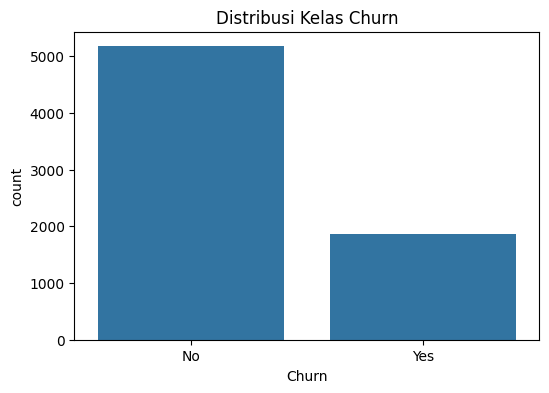


Cek Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [4]:
# Mengecek distribusi kolom target (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Distribusi Kelas Churn')
plt.show()

# Mengecek nilai kosong (missing values)
print("\nCek Missing Values:")
print(df.isnull().sum())

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
# 5. Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Mulai Preprocessing Data...")

# a. Menghapus kolom yang tidak relevan (customerID tidak ada hubungannya dengan churn)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# b. Memperbaiki tipe data TotalCharges (ubah teks kosong jadi NaN, lalu hapus baris yang kosong)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# c. Encoding Fitur Kategorikal
# Mengubah kolom target 'Churn' menjadi angka (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Mengubah fitur kategorikal (seperti gender, InternetService) menjadi angka (One-Hot Encoding)
df = pd.get_dummies(df, drop_first=True)

# d. Memisahkan Data (X = Fitur, y = Target)
X = df.drop('Churn', axis=1)
y = df['Churn']

# e. Membagi data menjadi Train Set (80%) dan Test Set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# f. Standardisasi (Scaling) Fitur Numerik agar rentang angkanya seimbang
scaler = StandardScaler()
numerik_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[numerik_cols] = scaler.fit_transform(X_train[numerik_cols])
X_test[numerik_cols] = scaler.transform(X_test[numerik_cols])

print("Preprocessing Selesai!")
print(f"Dimensi X_train: {X_train.shape}")
print(f"Dimensi X_test: {X_test.shape}")

Mulai Preprocessing Data...
Preprocessing Selesai!
Dimensi X_train: (5625, 30)
Dimensi X_test: (1407, 30)
